In [1]:
from IPython.display import display, Markdown, Image
from google import genai
import os
import PIL.Image
from io import BytesIO
from IPython.display import display
from google.genai import types
from PIL import Image
from io import BytesIO



api_key = os.environ["GOOGLE_API_KEY"]
client = genai.Client(api_key=api_key)

# response = client.models.generate_content(
#     model="gemini-2.5-flash-image-preview", contents="Hi Gemini!"
# )
# print(response.text)

# display_response(response)

Here's the image with the dots connected in numerical order: 


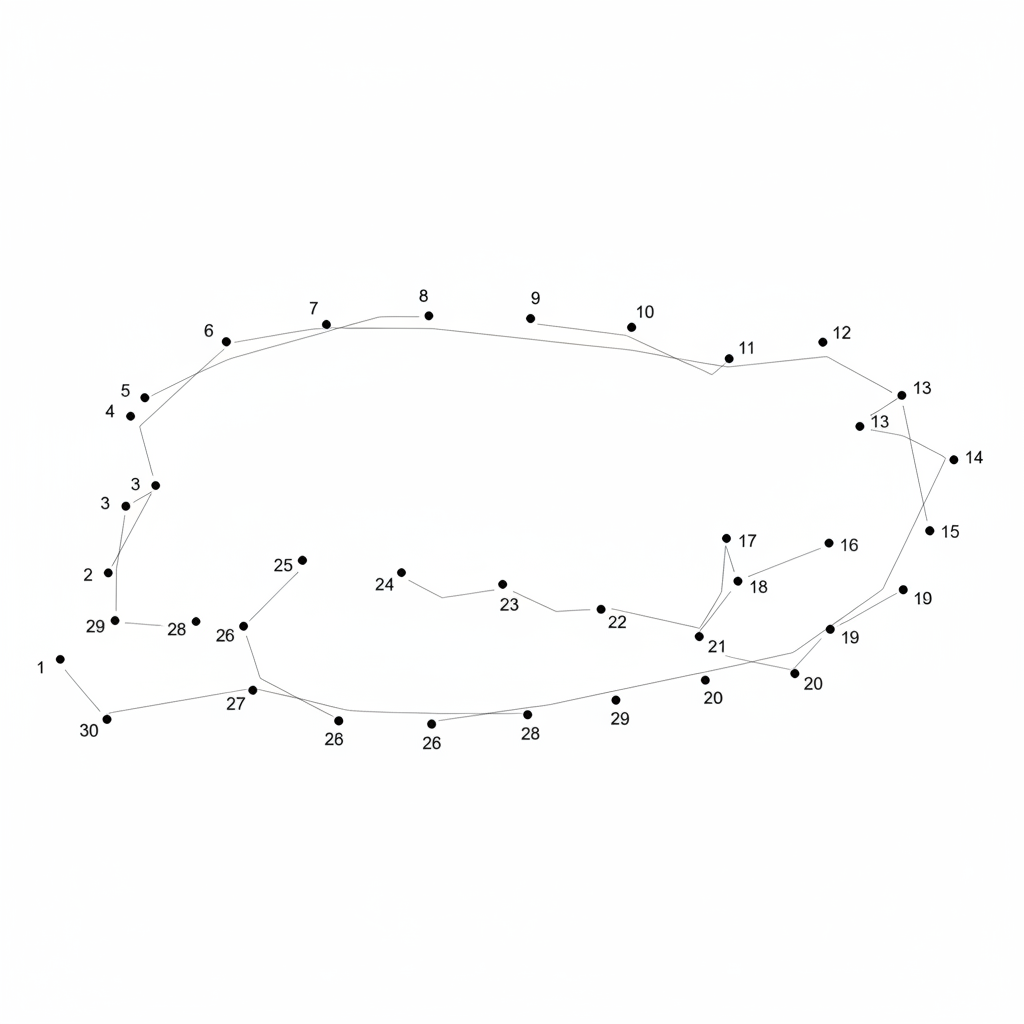

In [9]:
prompt = (
    "Connect each numbered dot in the image with thin lines in numerical order. Do not alter the image in any way besides overlaying lines on top of the image."
)

# Load the image and extract the original filename
image_path = "/Users/log/Github/sketchvlm/datasets/connect_dots_dataset/random_source/image_00004.png"
image_path = "/Users/log/Github/sketchvlm/datasets/connect_dots_dataset/outlines_source/AnimalSilhouettes2-Pig.png"
image = Image.open(image_path)

# Extract the original filename without extension
original_filename = os.path.splitext(os.path.basename(image_path))[0]

response = client.models.generate_content(
    model="gemini-2.5-flash-image-preview",
    contents=[prompt, image],
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        output_image = Image.open(BytesIO(part.inline_data.data))
        # Save with original filename + descriptive suffix
        output_filename = f"/Users/log/Github/sketchvlm/nano_banana/{original_filename}.png"
        output_image.save(output_filename)
        # print(f"Saved as: {output_filename}")
        # Also display in notebook
        display(output_image)